# Detección de contornos

En este cuaderno vas a estudiar cómo una región binaria se convierte en un borde que OpenCV puede recorrer y dibujar. Primero vamos a usar formas simples y después vamos a transferir la idea a una imagen real.


## Objetivo

Entender el pasaje máscara -> contorno y reconocer por qué la calidad de la máscara condiciona completamente el resultado final.

## Resultados de aprendizaje

Al finalizar este cuaderno, vas a poder:

- construir una máscara binaria controlada;
- usar `cv2.findContours()` para recuperar bordes;
- filtrar contornos por área;
- transferir el procedimiento a una imagen real segmentada por color.

## Relación con la secuencia

Este cuaderno prepara el terreno para medir propiedades geométricas. Antes de hablar de área, perímetro o centroides, conviene entender de dónde sale exactamente el contorno.


## Módulos que vamos a usar

- `cv2`: para construir máscaras, encontrar contornos y dibujarlos.
- `numpy`: para crear imágenes binarias simples.
- `matplotlib.pyplot`: para visualizar cada etapa.
- `pathlib.Path`: para abrir la imagen real de transferencia.


In [6]:
from pathlib import Path

import cv2
import numpy as np
import matplotlib.pyplot as plt


## 1. Empezar con una máscara simple

Cuando el objetivo es entender cómo funciona `findContours`, conviene empezar con una imagen binaria controlada. Así el foco queda en el mecanismo y no en errores previos de segmentación.


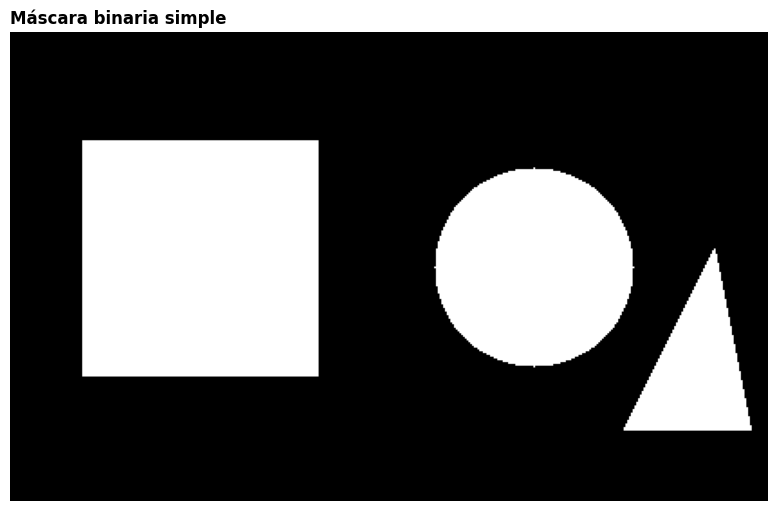

In [7]:
mascara_simple = np.zeros((260, 420), dtype=np.uint8)
cv2.rectangle(mascara_simple, (40, 60), (170, 190), 255, -1)
cv2.circle(mascara_simple, (290, 130), 55, 255, -1)
puntos_triangulo = np.array([[340, 220], [390, 120], [410, 220]], dtype=np.int32)
cv2.fillPoly(mascara_simple, [puntos_triangulo], 255)

plt.figure(figsize=(8, 5), constrained_layout=True)
plt.imshow(mascara_simple, cmap="gray")
plt.title("Máscara binaria simple", fontweight="bold", loc="left")
plt.axis("off")
plt.show()


## 2. Encontrar y dibujar contornos

`cv2.findContours()` no devuelve una imagen lista. Devuelve una lista de curvas. Después nosotros decidimos cómo mostrarlas.


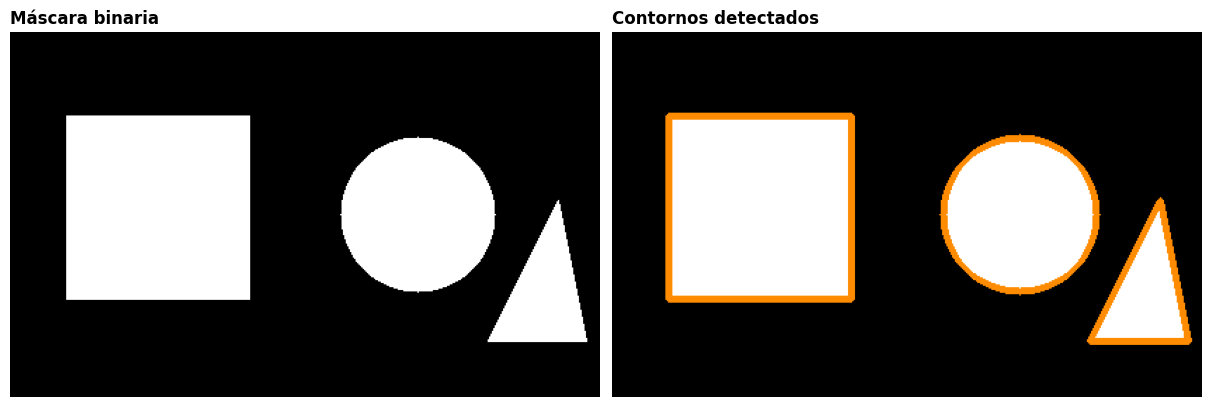

Cantidad de contornos detectados: 3


In [9]:
contornos_simples, _ = cv2.findContours(mascara_simple.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

imagen_contornos_simple = cv2.cvtColor(mascara_simple, cv2.COLOR_GRAY2RGB)
cv2.drawContours(imagen_contornos_simple, contornos_simples, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)
ejes[0].imshow(mascara_simple, cmap="gray")
ejes[0].set_title("Máscara binaria", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(imagen_contornos_simple)
ejes[1].set_title("Contornos detectados", fontweight="bold", loc="left")
ejes[1].axis("off")
plt.show()

print(f"Cantidad de contornos detectados: {len(contornos_simples)}")


En este ejemplo la relación entre máscara y contorno es directa. Eso ayuda a entender que el contorno no “descubre” el objeto por sí solo: sigue el borde de lo que la máscara ya definió como región blanca.


## 3. Transferir la idea a una imagen real

Ahora vamos a pasar a una imagen de globos. En este caso, primero necesitamos construir una máscara de color y después recién buscar los contornos.


In [17]:
ruta_globos = Path("Imagenes") / "globos.jpg"
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)
if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)

rango_naranja_bajo = np.array([8, 80, 80], dtype=np.uint8)
rango_naranja_alto = np.array([22, 255, 255], dtype=np.uint8)
mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)


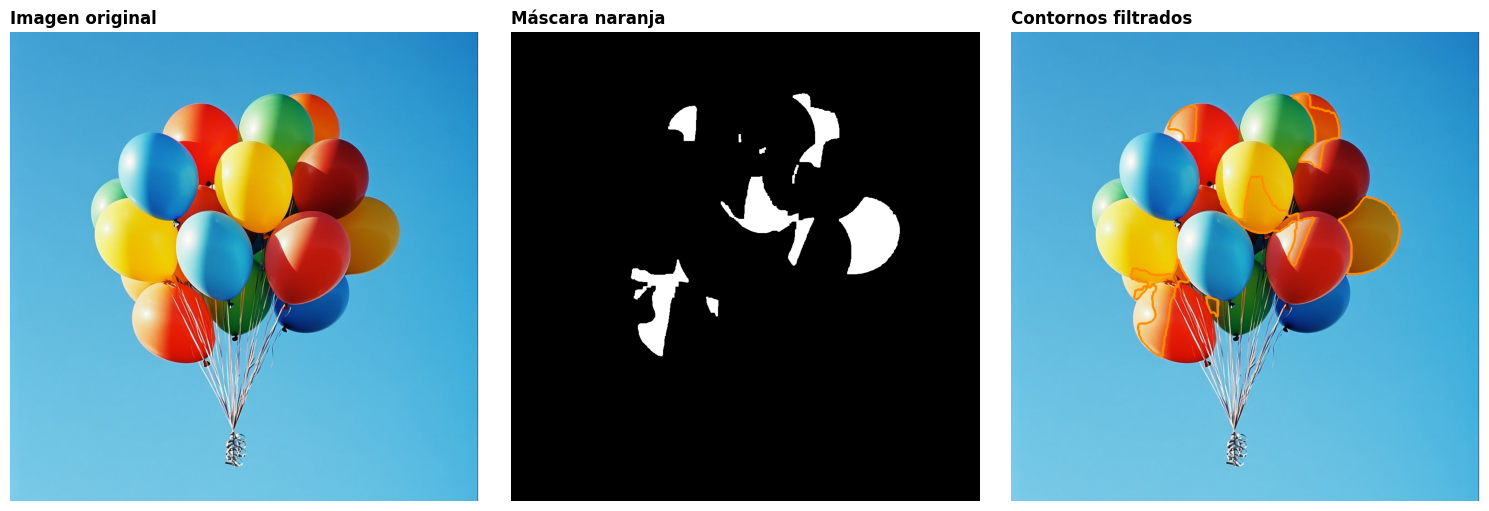

Contornos antes del filtrado: 9
Contornos conservados: 6


In [18]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []
for contorno in contornos_reales:
    if cv2.contourArea(contorno) > 500:
        contornos_filtrados.append(contorno)

imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray")
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos)
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")


Fijate que la calidad del contorno depende totalmente de la máscara. Si la segmentación deja ruido o se come partes del objeto, el contorno también queda mal. Por eso conviene pensar estas etapas como una cadena y no como funciones aisladas.


## Actividad breve

Modificá el rango de color o el criterio de área mínima y volvé a ejecutar el proceso. Después explicá:

1. qué cambió en la máscara;
2. qué cambió en los contornos detectados;
3. cuál sería un criterio razonable para decidir si un contorno vale la pena conservar.


In [ ]:
ruta_globos = Path("Imagenes") / "globos.jpg"
imagen_globos_bgr = cv2.imread(str(ruta_globos), cv2.IMREAD_COLOR)
if imagen_globos_bgr is None:
    raise FileNotFoundError(f"No se pudo leer la imagen: {ruta_globos}")

imagen_globos_rgb = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2RGB)
imagen_globos_hsv = cv2.cvtColor(imagen_globos_bgr, cv2.COLOR_BGR2HSV)

rango_naranja_bajo = np.array([5, 100, 100], dtype=np.uint8)   # antes: [8, 80, 80]
rango_naranja_alto = np.array([25, 255, 255], dtype=np.uint8)  # antes: [22, 255, 255]
mascara_naranja = cv2.inRange(imagen_globos_hsv, rango_naranja_bajo, rango_naranja_alto)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_OPEN, np.ones((5, 5), dtype=np.uint8), iterations=1)
mascara_naranja = cv2.morphologyEx(mascara_naranja, cv2.MORPH_CLOSE, np.ones((5, 5), dtype=np.uint8), iterations=2)

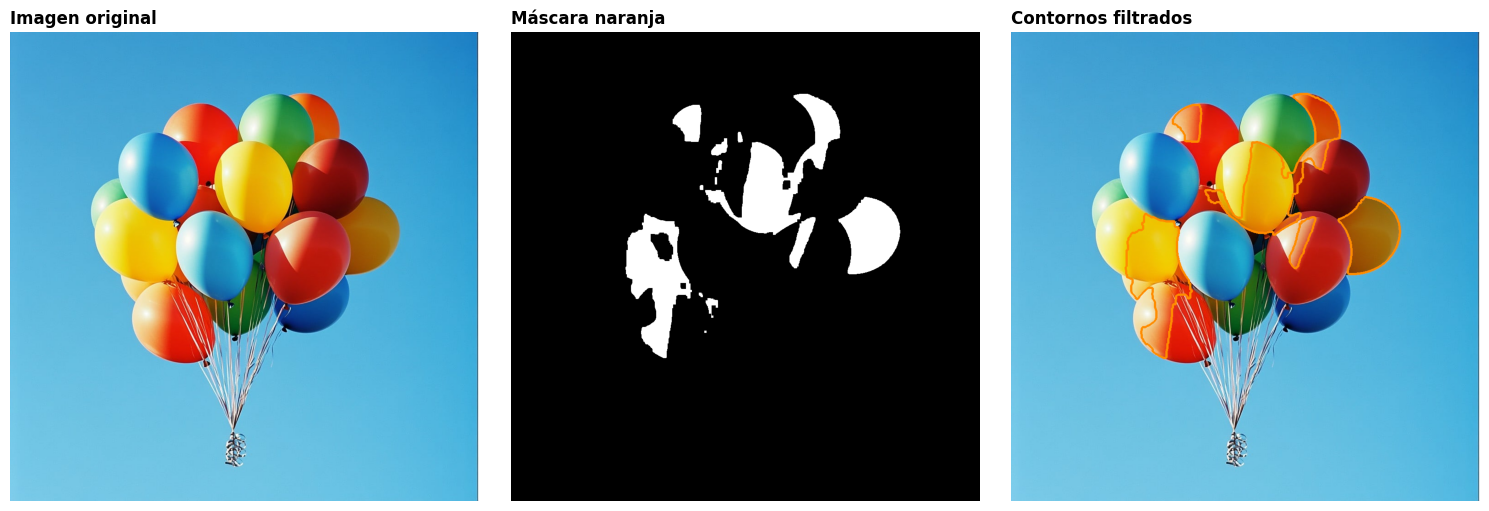

Contornos antes del filtrado: 13
Contornos conservados: 5


In [16]:
contornos_reales, _ = cv2.findContours(mascara_naranja.copy(), cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)

contornos_filtrados = []
for contorno in contornos_reales:
    if cv2.contourArea(contorno) > 1500:   # antes: 500
        contornos_filtrados.append(contorno)

imagen_con_contornos = imagen_globos_rgb.copy()
cv2.drawContours(imagen_con_contornos, contornos_filtrados, -1, (255, 140, 0), 3)

fig, ejes = plt.subplots(1, 3, figsize=(15, 5), constrained_layout=True)
ejes[0].imshow(imagen_globos_rgb)
ejes[0].set_title("Imagen original", fontweight="bold", loc="left")
ejes[0].axis("off")
ejes[1].imshow(mascara_naranja, cmap="gray")
ejes[1].set_title("Máscara naranja", fontweight="bold", loc="left")
ejes[1].axis("off")
ejes[2].imshow(imagen_con_contornos)
ejes[2].set_title("Contornos filtrados", fontweight="bold", loc="left")
ejes[2].axis("off")
plt.show()

print(f"Contornos antes del filtrado: {len(contornos_reales)}")
print(f"Contornos conservados: {len(contornos_filtrados)}")

1. ¿Qué cambió en la máscara?

Al bajar el límite inferior de H de 8 a 5 y subir el superior de 22 a 25, la máscara captura un rango tonal más amplio. Esto tiene dos efectos opuestos:

Las regiones blancas del globo naranja quedan más completas y conectadas (menos agujeros internos), porque se incluyen píxeles de bordes con tono levemente desviado por la iluminación o sombra.
Al mismo tiempo, pueden aparecer nuevas regiones espurias pequeñas si algún otro objeto en la escena tiene un tono similar (por ejemplo, reflejos cálidos en el cielo o en otros globos).

Subir los valores mínimos de S y V de 80 a 100 en cambio hace lo contrario: filtra mejor el ruido de píxeles desaturados o muy oscuros que técnicamente caen en el rango de matiz naranja pero no son realmente ese color.

2. ¿Qué cambió en los contornos detectados?

Con la máscara más completa (menos agujeros), los contornos de los globos naranjas quedan más cerrados y continuos, en lugar de aparecer fragmentados en varios pedazos como se ve en tu resultado actual. Fijate que en tu imagen la máscara muestra varias manchas blancas separadas donde debería haber uno o dos globos: eso genera múltiples contornos chicos para lo que conceptualmente es un solo objeto.

Al subir el umbral de área a 1500, los fragmentos pequeños que sí pasaban el filtro anterior (>500 px²) ahora se descartan, así que los "contornos conservados" bajan, pero los que quedan corresponden mejor a objetos reales. El resultado esperado sería pasar de 6 conservados a quizás 2 o 3, pero mucho más representativos.

3. ¿Cuál sería un criterio razonable para decidir si un contorno vale la pena conservar?

El área mínima sola no alcanza, porque un fragmento alargado y raro puede tener mucha área y no ser un objeto real. Un criterio más sólido combina dos cosas: que el contorno sea suficientemente grande en relación a la imagen, y que tenga una forma razonablemente compacta, es decir, que no sea un hilo o una mancha extraña sino algo que se parezca a un objeto real. En el caso de los globos, que son aproximadamente circulares, un contorno muy irregular o muy chico probablemente es ruido de la segmentación y no vale la pena conservarlo.


## Cierre

Detectar contornos no es solo llamar a `findContours()`. Antes hace falta una máscara que represente bien el objeto de interés. Cuando esa etapa previa está bien resuelta, el contorno se vuelve una herramienta muy útil para medir, comparar y describir formas.
